In [1]:
import sys
sys.path.append('../src/')
from xpcs import *
from sims import *
from autocorrelations import *
import cv2
from scipy.special import erfinv
from scipy.special import erf
import pyopencl as cl
from pathlib import Path
import json
import tqdm as tqdm



%matplotlib notebook


In [4]:
Compound    = "NPS"
Particle    = 2
Scan        = np.array([219,334,416,552,579,709,779,796,868])
Temperature = np.array([298,305,315,325,345,365,385,405,450])

# XRD Loop

In [5]:
# Define the path to the configuration file
config_path = Path(f"{Compound}_base_config.json")

# Open and load the JSON configuration file
with open(config_path, "r") as file:
    config = json.load(file)
    
i = 0

for s,t in zip(Scan,Temperature):

    BASE_DIR  = Path(config.get(f"particle{Particle}_scan{s}_temp{t}K"))
    filename  = f'{Compound}_01_00{s}_master.h5'
    batchname = f'{Compound}_01_00{s}.batchinfo'

    file_path = BASE_DIR / filename
    batch_path = BASE_DIR / batchname

    metadata = h5py.File(file_path, 'r') # hdf file contains metadata for the measurement

    batchinfo = load_batchinfo(batch_path,':') # batchinfo contains other parameters

    try:
        #Load Parameters From .h5 file
        frame_spacing=np.array(metadata['/entry/instrument/detector/frame_time']);
        wavelength = np.array(metadata['entry/instrument/beam/incident_wavelength']) #Wavelength [Å]
        x_pixel_size = np.array(metadata['entry/instrument/detector/x_pixel_size/']) # [m]
        pixelSize = x_pixel_size*10**3 # [mm]

        #print_h5_item(metadata) uncomment to print contents

    finally: 
        #Close h5 file
        metadata.close()

    #Load Parameters From batchinfo
    X0 = batchinfo['x0'] #horizontal beam position
    Y0 = batchinfo['y0'] #vertical beam position
    ttheta = batchinfo['ccdtth'] #Detector posistion [deg]
    ccdz = batchinfo['ccdz']
    ccdz0 = batchinfo['ccdz0']
    D = batchinfo['rr'] # Sample to detector [mm]
    horBeg = batchinfo['col_beg']
    horEnd = batchinfo['col_end']
    verBeg = batchinfo['row_beg']
    verEnd = batchinfo['row_end']
    samy   = batchinfo['samx'] #this is mislabeled in the batchinfo. Actually samy
    samz   = batchinfo['samz']
    samth  = batchinfo['samth']
    detDims = np.array([[horBeg, horEnd],[verBeg,verEnd]]) 

    det = np.array(h5py.File(file_path, 'r')['entry/data/data_000001/'])[:,:,:] #Used for preprocessing
    det_corr = np.copy(det) #Used for g2 correlations



    #Remove hot pixels
    det[det>100] = 0 
    
    if i==0:
        xrds_sum = np.zeros((Scan.shape[0],det.shape[2]))
        xrds_mean = np.zeros((Scan.shape[0],det.shape[2]))
        
    xrds_sum[i,:]+=np.sum(np.sum(det,axis=0),axis=0)
    xrds_mean[i,:]+=np.mean(np.mean(det,axis=0),axis=0)
    
    i+=1

JSONDecodeError: Expecting property name enclosed in double quotes: line 29 column 1 (char 4319)

<IPython.core.display.Javascript object>


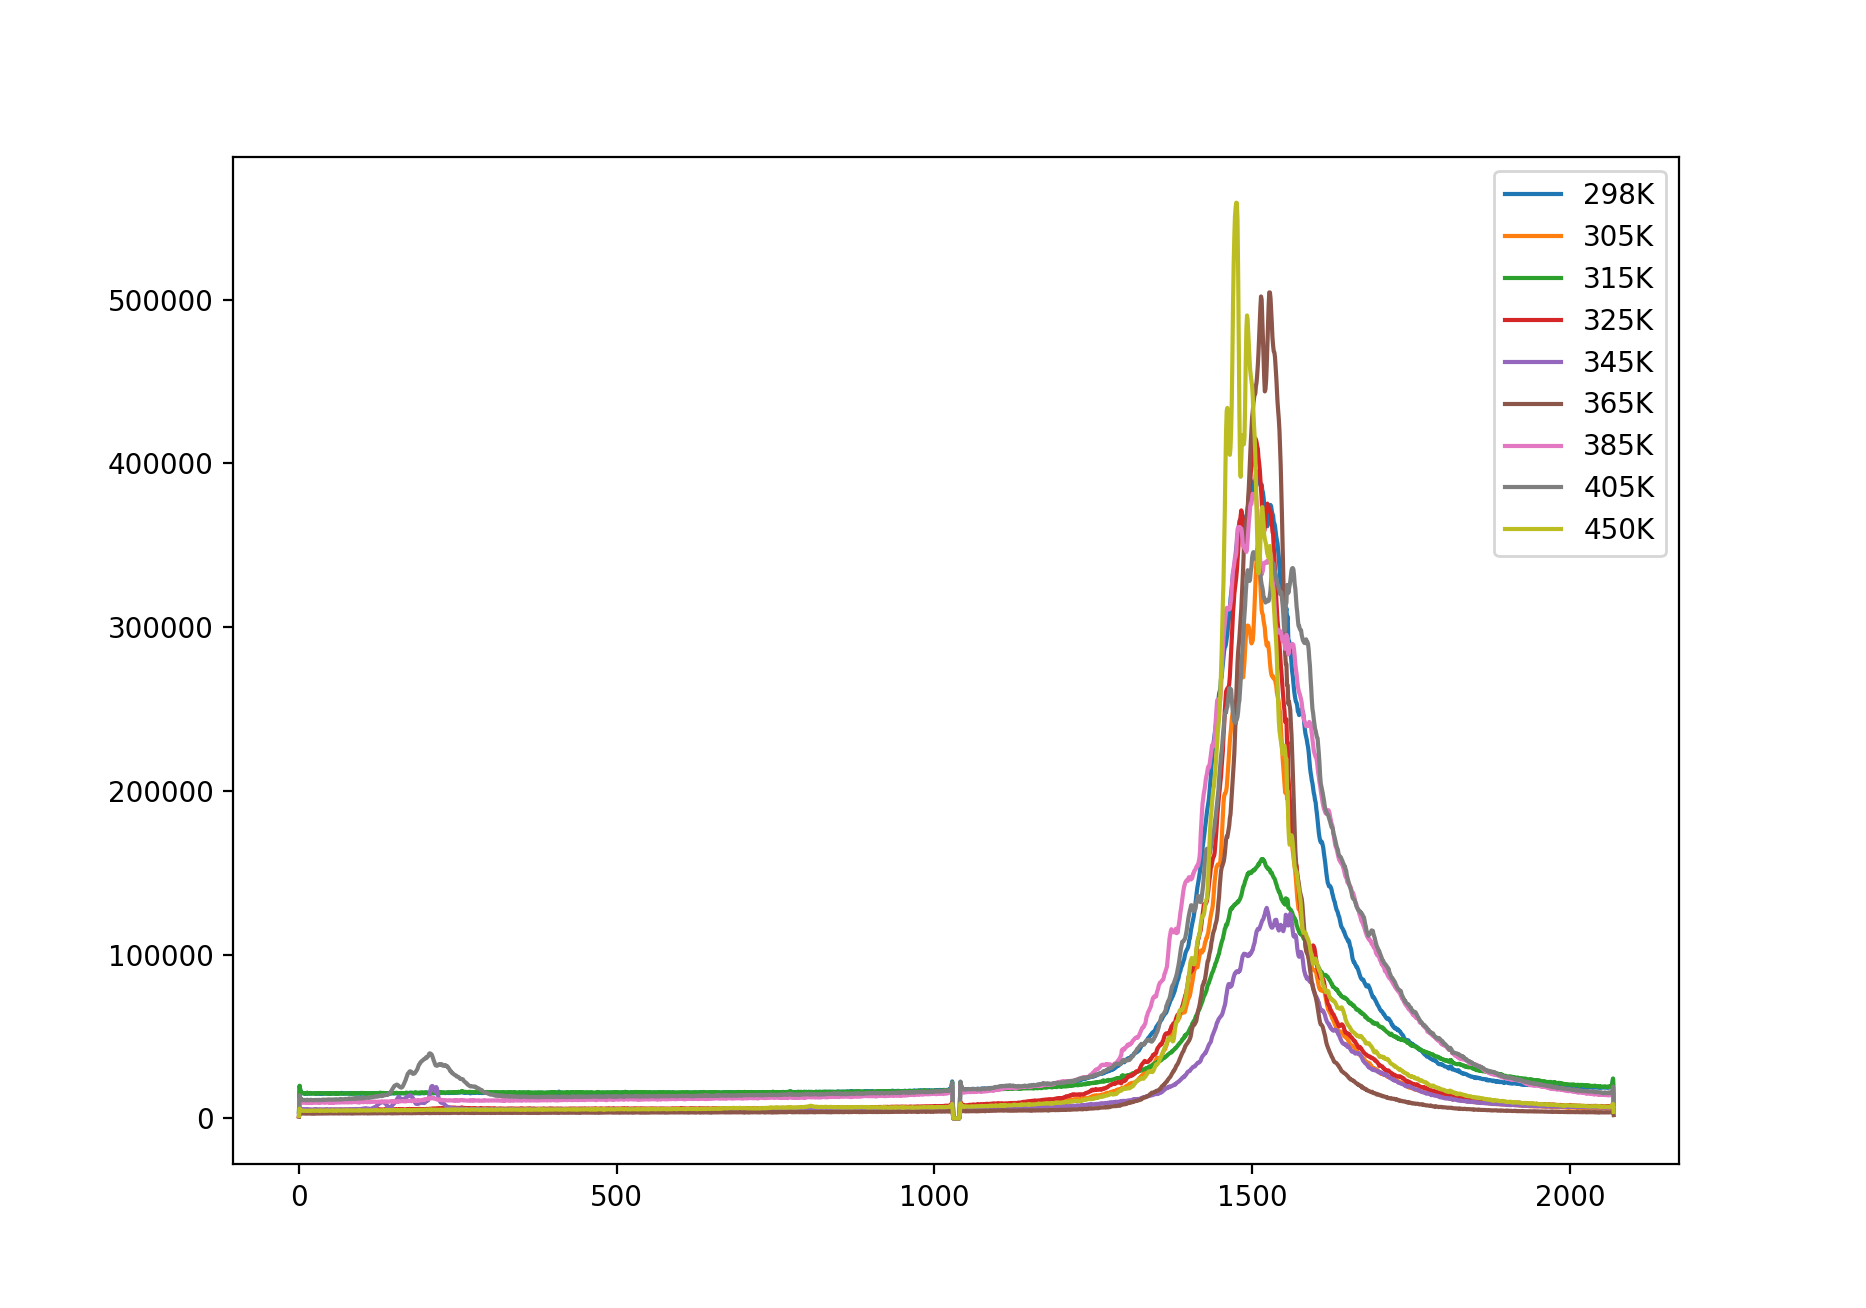

In [51]:
fig,ax = plt.subplots()

for i,xs in enumerate(xrds_sum):
    #if Temperature[i] != 345 and Temperature[i] != 315: 
    ax.plot(xs,label=f'{Temperature[i]}K')
    
ax.legend()

# Fit Each One

In [25]:
POPT = np.zeros((xrds_sum.shape[0],4))
ERR = np.zeros((xrds_sum.shape[0],4))

std = 100
x = np.arange(xrds_sum.shape[1])
for i,xs in enumerate(xrds_sum):
    
    popt, pcov = curve_fit(gaussian, x, xs, p0=[np.max(xs), np.argmax(xs) , std, np.min(xs[np.nonzero(xs)])])
    POPT[i,:] += popt
    ERR[i,:]  += np.sqrt(np.diag(pcov))

<IPython.core.display.Javascript object>


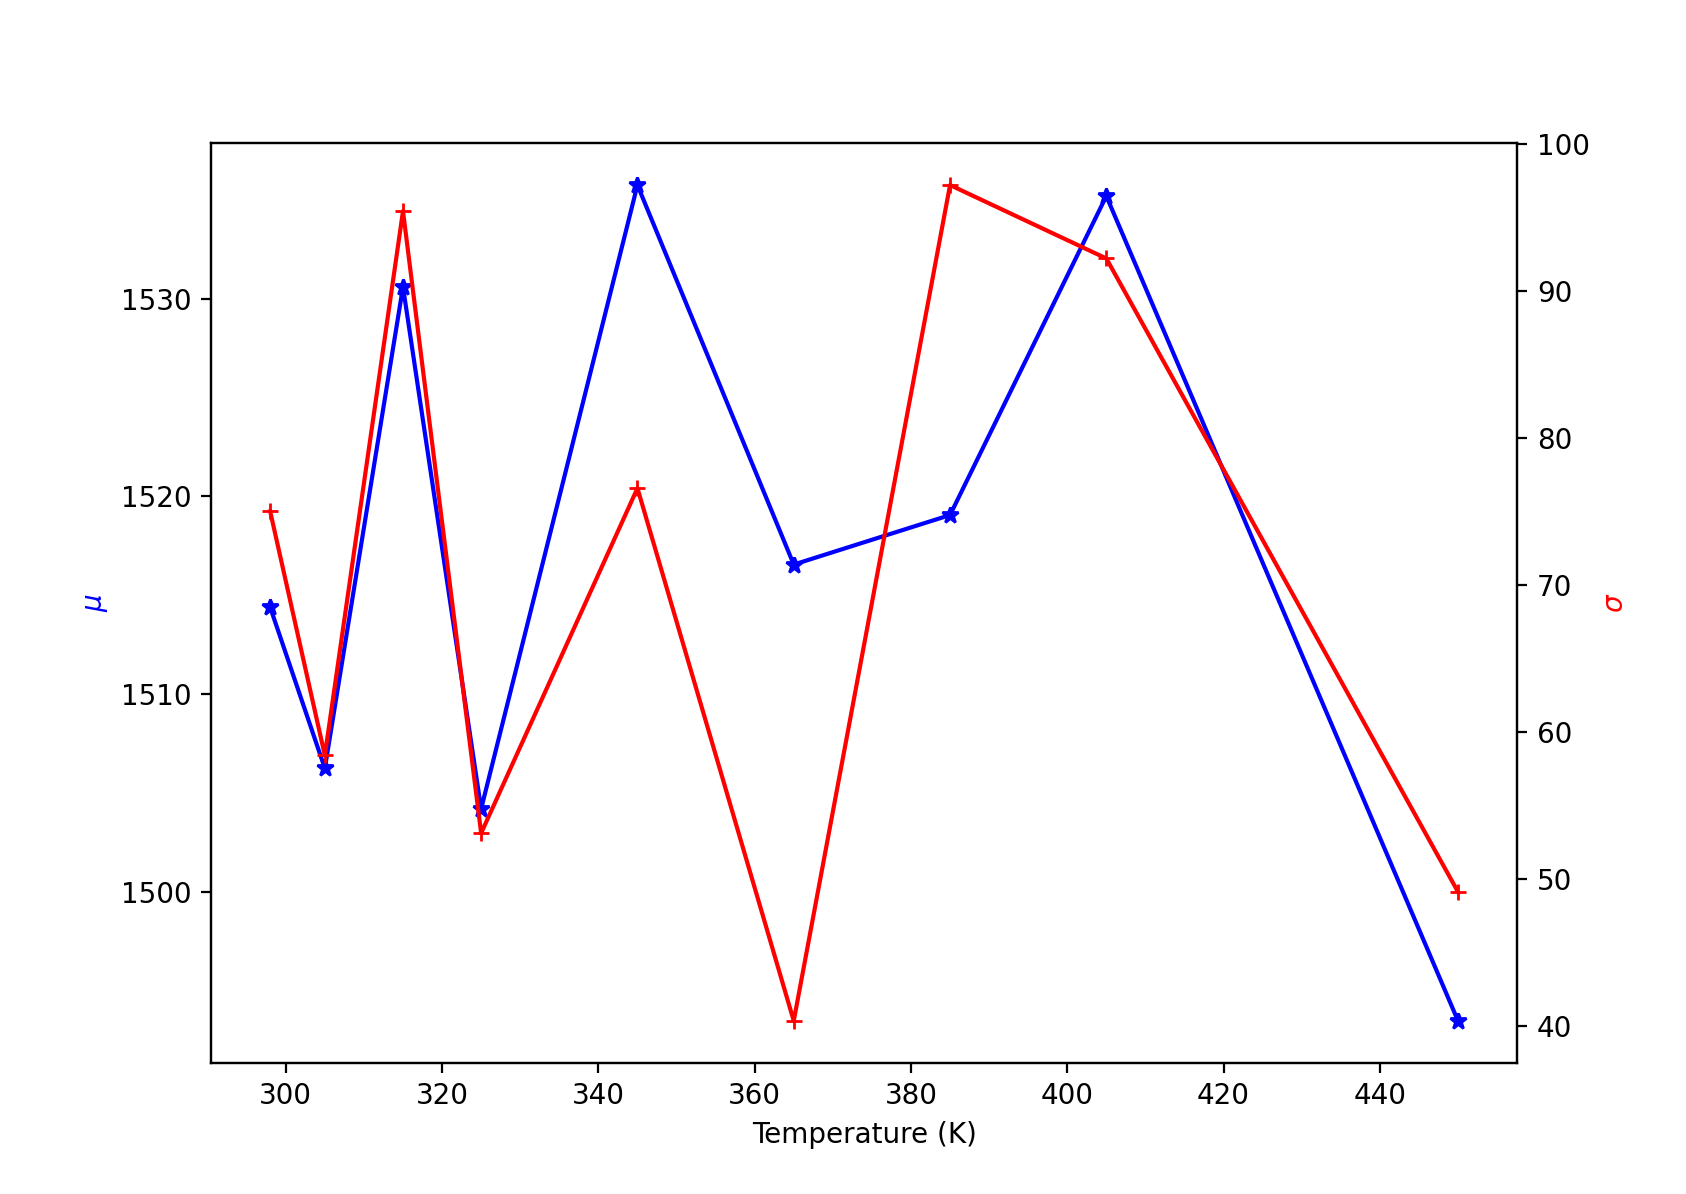

Text(0, 0.5, '$\\mu$')

In [37]:
fig,ax = plt.subplots()
ax2 = ax.twinx()

ax.plot(Temperature,POPT[:,1],'b*-')
ax2.plot(Temperature,POPT[:,2],'r+-')

    
ax.set_xlabel('Temperature (K)')
ax2.set_ylabel('$\\sigma$',color='red')
ax.set_ylabel('$\\mu$',color='blue')

<IPython.core.display.Javascript object>


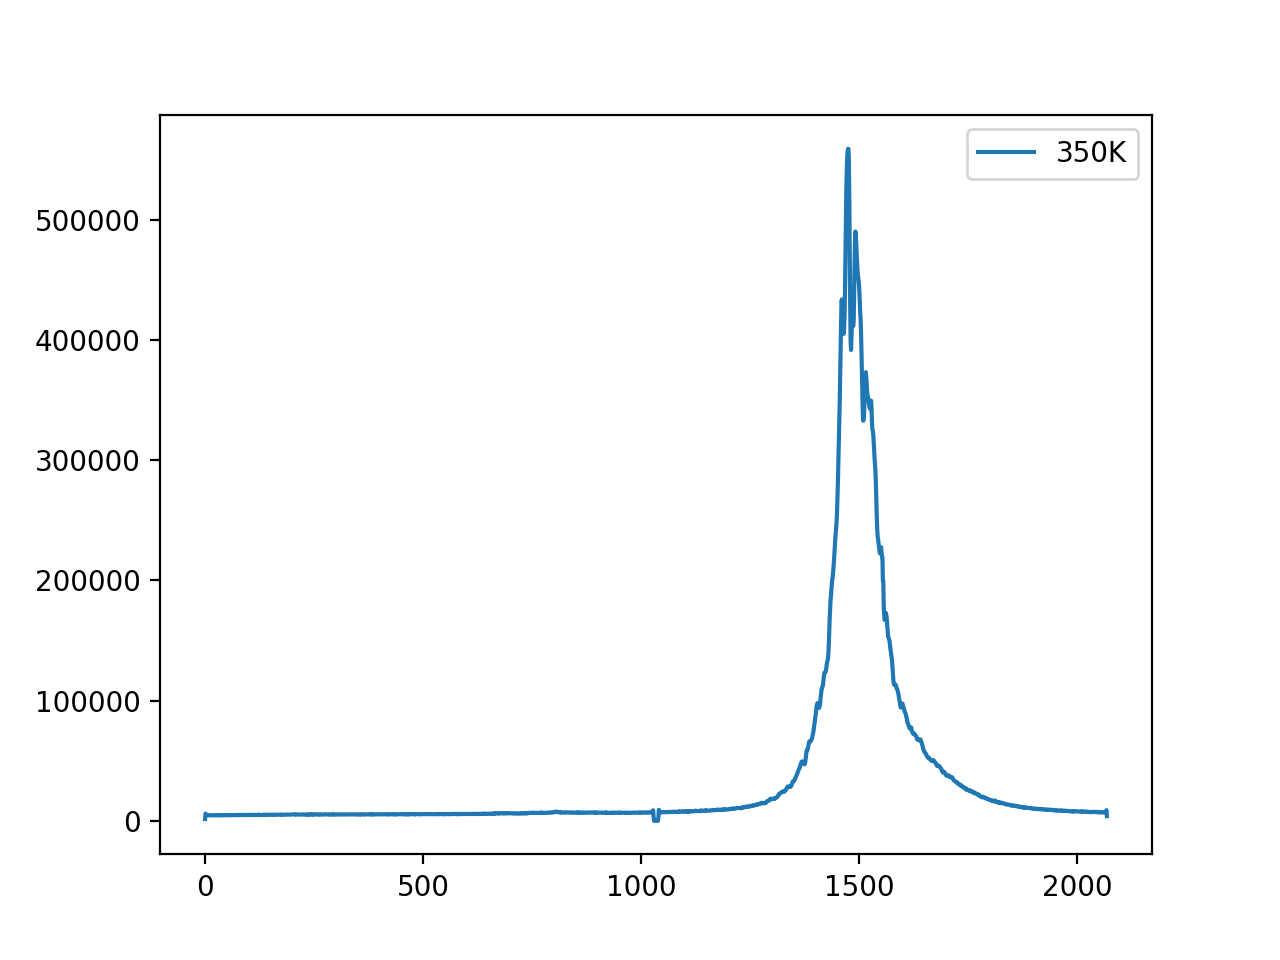

In [50]:
fig,ax = plt.subplots()

ind = np.where(Temperature==365)[0][0]
#ax.plot(xrds_sum[ind-2,:],label=f'{Temperature[ind-2]}K')

#ax.plot(xrds_sum[ind,:],label=f'{Temperature[ind]}K')
#ax.plot(xrds_sum[ind+1,:],label=f'{Temperature[ind+1]}K')
#ax.plot(xrds_sum[ind+2,:],label=f'{Temperature[ind+2]}K')
ax.plot(xrds_sum[ind+3,:],label=f'{Temperature[ind+3]-100}K')


    
ax.legend()

In [41]:
print(np.where(Temperature==365)[0][0])

5
